## **SP500 Financial Modeling**

#### **Prepared by: Ayu Putri Vidiantiwi**

In [2]:
# Import & Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

# Load dataset
df = pd.read_csv("/Users/putri/Downloads/financial data sp500 companies.csv")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2012 entries, 0 to 2011
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Unnamed: 0                              2012 non-null   int64  
 1   date                                    2012 non-null   object 
 2   firm                                    2012 non-null   object 
 3   Ticker                                  2012 non-null   object 
 4   Research Development                    634 non-null    float64
 5   Income Before Tax                       2011 non-null   float64
 6   Net Income                              2012 non-null   float64
 7   Selling General Administrative          1952 non-null   float64
 8   Gross Profit                            2012 non-null   float64
 9   Ebit                                    2012 non-null   float64
 10  Operating Income                        2011 non-null   floa

#### Cleaning & Feature Prep


In [3]:
# Drop useless index column
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Parse date
df["date"] = pd.to_datetime(df["date"], format="mixed")

# Sort
df = df.sort_values(["Ticker", "date"]).reset_index(drop=True)

# Create Year & Quarter
df["Year"] = df["date"].dt.year
df["Quarter"] = df["date"].dt.quarter

df.head()

,date,firm,Ticker,Research Development,Income Before Tax,Net Income,Selling General Administrative,Gross Profit,Ebit,Operating Income,Interest Expense,Income Tax Expense,Total Revenue,Total Operating Expenses,Cost Of Revenue,Total Other Income Expense Net,Net Income From Continuing Ops,Net Income Applicable To Common Shares,Year,Quarter
0,2020-10-31,Agilent Technologies,A,102000000.0,2.830000e+08,2.220000e+08,342000000.0,7.880000e+08,3.440000e+08,3.440000e+08,-19000000.0,61000000.0,1.483000e+09,1.139000e+09,6.950000e+08,-61000000.0,2.220000e+08,2.220000e+08,2020,4
1,2021-01-31,Agilent Technologies,A,103000000.0,3.120000e+08,2.880000e+08,398000000.0,8.380000e+08,3.370000e+08,3.370000e+08,-19000000.0,24000000.0,1.548000e+09,1.211000e+09,7.100000e+08,-25000000.0,2.880000e+08,2.880000e+08,2021,1
2,2021-04-30,Agilent Technologies,A,109000000.0,2.730000e+08,2.160000e+08,420000000.0,8.170000e+08,2.880000e+08,2.880000e+08,-20000000.0,57000000.0,1.525000e+09,1.237000e+09,7.080000e+08,-15000000.0,2.160000e+08,2.160000e+08,2021,2
3,2021-07-31,Agilent Technologies,A,113000000.0,3.270000e+08,2.640000e+08,390000000.0,8.520000e+08,3.490000e+08,3.490000e+08,-21000000.0,63000000.0,1.586000e+09,1.237000e+09,7.340000e+08,-22000000.0,2.640000e+08,2.640000e+08,2021,3
4,2020-09-30,American Airlines Group,AAL,NaN,-3.095000e+09,-2.399000e+09,70000000.0,-2.489000e+09,-3.716000e+09,-3.716000e+09,-340000000.0,-696000000.0,3.173000e+09,6.889000e+09,5.662000e+09,621000000.0,-2.399000e+09,-2.399000e+09,2020,3


#### Create Ratio Feature

In [4]:
df["GrossMargin"] = df["Gross Profit"] / df["Total Revenue"]
df["OperatingMargin"] = df["Operating Income"] / df["Total Revenue"]
df["NetMargin"] = df["Net Income"] / df["Total Revenue"]
df["RD_Ratio"] = df["Research Development"] / df["Total Revenue"]
df["SGA_Ratio"] = df["Selling General Administrative"] / df["Total Revenue"]


In [5]:
df[["GrossMargin","OperatingMargin","NetMargin","RD_Ratio","SGA_Ratio"]].describe()

,GrossMargin,OperatingMargin,NetMargin,RD_Ratio,SGA_Ratio
count,2010.000000,2011.000000,2010.000000,634.000000,1952.000000
mean,0.379127,inf,-0.395571,0.103784,inf
std,1.799395,NaN,10.872653,0.080411,NaN
min,-63.791935,-184.310968,-441.997419,0.000356,-0.286201
25%,0.309820,0.113108,0.062007,0.041783,0.076667
50%,0.455287,0.185690,0.124556,0.082992,0.164917
75%,0.639312,0.276607,0.211760,0.152308,0.267739
max,1.097731,inf,4.023238,0.602889,inf


### **Interpretation of Ratio Feature Summary**

The table summarizes the distribution of five key profitability and efficiency ratios generated from the S&P 500 financial dataset: **Gross Margin**, **Operating Margin**, **Net Margin**, **R&D Ratio**, and **SG&A Ratio**. These ratios help evaluate how effectively firms convert revenue into profit and how they allocate expenses toward operations and innovation.

#### **1. Gross Margin**

* **Mean ≈ 0.38** indicates that, on average, firms retain about **38% of revenue** after accounting for direct costs.
* The **50th percentile (median ≈ 0.46)** shows that half of the firms have gross margins above 46%, which is typical for companies with strong pricing power or efficient cost structures.
* However, the **minimum value of –63.8%** and a very large **standard deviation (1.79)** suggest the presence of outliers, possibly distressed firms or companies with unusual cost accounting.

#### **2. Operating Margin**

* The table shows **inf** (infinite) mean and **inf** maximum values, indicating division by zero occurred for some companies with zero revenue but positive operating income.
* The **minimum value (–184%)** highlights firms operating at substantial losses, which is common in early-stage growth companies or firms restructuring operations.
* Given these anomalies, operating margin should be cleaned further by removing rows with zero revenue or capping extreme values.

#### **3. Net Margin**

* The **mean (–0.395)** suggests that many firms report negative net margins, driven by extraordinary expenses, interest costs, or one-time losses.
* The **range is wide**, from **–442% to +402%**, reflecting substantial variability across sectors.
* The median (**0.12**) shows that a typical firm has a net margin of around 12%, which is much more reasonable than the extreme values.

#### **4. R&D Ratio**

* The **mean (0.10)** indicates that companies typically spend around **10% of revenue on R&D**, consistent with industries where innovation is critical (tech, biotech).
* The distribution is tight, with **std ≈ 0.08**, and values are mostly positive, indicating that R&D intensity is relatively stable across reporting firms.

#### **5. SG&A Ratio**

* The SG&A ratio also shows extreme values including **inf**, again due to inconsistencies tied to companies with zero or near-zero revenue.
* The median (≈ 0.16) suggests that a typical firm spends around **16% of revenue** on selling, general, and administrative expenses.
* Higher SG&A ratios usually reflect heavy marketing or corporate overhead, common in retail, tech, and consumer discretionary firms.


#### **Overall Insights**

* The ratio features provide valuable signals about cost structure, profitability, and spending intensity across S&P 500 firms.
* The presence of extreme values (∞, negative margins below –100%) indicates that the raw dataset includes firms with revenue distortions, losses, or unusual accounting periods.
* Before performing machine learning or clustering, additional cleaning—such as removing zero-revenue rows or winsorizing extreme outliers—will improve the reliability of downstream analysis.

---


#### Firm-Level Summary

In [6]:
firm_summary = df.groupby(["firm", "Ticker"]).agg(
    AvgRevenue=("Total Revenue", "mean"),
    AvgNetIncome=("Net Income", "mean"),
    GrossMargin=("GrossMargin", "mean"),
    OperatingMargin=("OperatingMargin", "mean"),
    NetMargin=("NetMargin", "mean"),
    RD_Ratio=("RD_Ratio", "mean"),
    SGA_Ratio=("SGA_Ratio", "mean")
).reset_index()

firm_summary.head()


,firm,Ticker,AvgRevenue,AvgNetIncome,GrossMargin,OperatingMargin,NetMargin,RD_Ratio,SGA_Ratio
0,3M,MMM,8.831500e+09,1.492750e+09,0.478397,0.226224,0.168990,0.055599,0.196574
1,A. O. Smith,AOS,8.444750e+08,1.168750e+08,0.377388,0.170911,0.138052,NaN,0.206477
2,ADM,ADM,2.003425e+10,6.535000e+08,0.071536,0.034168,0.032900,NaN,0.036923
3,AES Corp,AES,2.732750e+09,1.352500e+08,0.263691,0.247359,0.047850,NaN,0.016332
4,APA Corporation,APA,1.506750e+09,1.775000e+08,0.634061,-0.698778,0.094691,NaN,0.050729


The table presents an aggregated financial profile for each S&P 500 company, summarizing average revenue, profitability, and expense structure based on the available historical data. Each row represents one firm, with metrics averaged across the dataset’s time period.

#### **1. Revenue & Profit Levels**
* **AvgRevenue** shows the average annual revenue scale of a firm.
  * For example, **3M (MMM)** generates approximately **$8.8 billion** per year.
  * **APA Corporation (APA)** is much smaller, with around **$1.5 billion** annually.
  * Revenue differences highlight fundamental differences in business scale and market presence.

* **AvgNetIncome** indicates the average annual profit.
  * 3M remains consistently profitable (**$1.49B** net income).
  * APA Corporation’s profit (**$177M**) is modest relative to its revenue, suggesting lower profitability or more volatile earnings.

#### **2. Profit Margins**
Margins explain how efficiently each firm turns revenue into profit:

* **GrossMargin** reflects how much profit remains after production costs.
  * APA shows a very high gross margin (**0.63**), suggesting strong pricing power or unusually low cost of revenue.
  * ADM’s gross margin (**0.07**) indicates a very thin spread typical of commodity-driven industries.

* **OperatingMargin** reveals how well a firm manages operating expenses.
  * AES Corp has strong operational efficiency (**0.247**).
  * APA shows a **negative operating margin (-0.699)**, implying operating losses despite healthy gross margins—often due to high SG&A, restructuring costs, or impairments.

* **NetMargin** captures final profitability after all expenses.

  * 3M maintains strong net profitability (**0.169**), consistent with stable industrial operations.
  * ADM and AES show much lower net margins (**0.03–0.04**), typical for their sectors.

#### **3. Expense Ratios**
* **RD_Ratio** measures how much revenue is invested in research and development.

  * 3M invests ~**5.5%** of its revenue into innovation.
  * Some firms (e.g., APA, ADM) have **NaN** values because R&D is not a material part of their business model.

* **SGA_Ratio** captures selling and administrative overhead.

  * 3M spends around **19.7%** on SG&A, typical for diversified manufacturers.
  * AES Corp’s SG&A ratio is much smaller (**0.016**), consistent with utility companies that have fewer selling expenses.

#### **4. Cross-Firm Observations**
* Firms differ widely in size, profitability, and expense structure, reflecting their industries.
* High gross margins don’t guarantee strong operating or net margins—APA is the clearest example.
* Missing R&D values are normal for sectors where R&D is not a standard cost category.
* SG&A levels vary significantly by industry, influencing operating leverage and profitability.

---


#### Profitability Ranking

In [7]:
firm_summary.sort_values("NetMargin", ascending=False).head(10)

,firm,Ticker,AvgRevenue,AvgNetIncome,GrossMargin,OperatingMargin,NetMargin,RD_Ratio,SGA_Ratio
66,Bio-Rad Laboratories,BIO,7.199572e+08,1.011364e+09,0.573565,0.198592,1.428844,0.086571,0.288403
501,eBay,EBAY,2.695000e+09,3.221000e+09,0.751991,0.275760,1.203913,0.115202,0.327749
437,The Cooper Companies,COO,7.112500e+08,7.289000e+08,0.692404,0.224346,1.044169,0.032633,0.384732
391,Regeneron Pharmaceuticals,REGN,3.339050e+09,1.748875e+09,0.623905,0.505576,0.507679,NaN,0.137047
380,Public Storage,PSA,8.345670e+08,4.212050e+08,0.732829,0.509310,0.503938,NaN,0.029106
465,Verisign,VRSN,3.227972e+08,1.566048e+08,0.856149,0.646332,0.485562,0.061368,0.148448
56,AvalonBay Communities,AVB,5.586660e+08,2.697518e+08,0.620669,0.270050,0.483729,NaN,0.027864
471,Visa,V,5.661750e+09,2.716000e+09,0.967637,0.646789,0.479217,NaN,0.278859
20,Alexandria Real Estate Equities,ARE,5.034442e+08,2.344590e+08,0.709925,0.262048,0.475140,NaN,0.070773
183,Extra Space Storage,EXR,3.669510e+08,1.604088e+08,0.753572,0.509271,0.436040,NaN,0.086542


The ranking highlights the S&P 500 firms with the **highest average net margins** across the available dataset. Net margin measures how much profit remains after covering all operating costs, interest, and taxes, expressed as a percentage of revenue. A higher net margin indicates stronger profitability, operational efficiency, and cost discipline.

#### Cluster Companies by Financial Profile

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ["GrossMargin","OperatingMargin","NetMargin","RD_Ratio","SGA_Ratio"]
firm_clean = firm_summary.dropna(subset=features)

X = firm_clean[features].values
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
firm_clean["Cluster"] = kmeans.fit_predict(X_scaled)

firm_clean.head(20)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/var/folders/g5/yk28jtxx38l8s2gkxsnln3sr0000gn/T/ipykernel_74346/540090124.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  firm_clean["Cluster"] = kmeans.fit_predict(X_scaled)


,firm,Ticker,AvgRevenue,AvgNetIncome,GrossMargin,OperatingMargin,NetMargin,RD_Ratio,SGA_Ratio,Cluster
0,3M,MMM,8.831500e+09,1.492750e+09,0.478397,0.226224,0.168990,0.055599,0.196574,1
6,AbbVie,ABBV,1.379225e+10,1.883500e+09,0.701651,0.352703,0.138057,0.126913,0.214536,0
7,Abbott Laboratories,ABT,1.057700e+10,1.811000e+09,0.580117,0.219158,0.170498,0.062026,0.250674,0
8,Abiomed,ABMD,2.434088e+08,3.728800e+07,0.818946,0.269698,0.156810,0.146237,0.403011,2
10,Activision Blizzard,ATVI,2.263250e+09,6.607500e+08,0.727724,0.363746,0.293336,0.151072,0.212906,0
11,Adobe,ADBE,3.774750e+09,1.459750e+09,0.881519,0.365004,0.394764,0.161690,0.343497,0
13,Advanced Micro Devices,AMD,3.713000e+09,9.922500e+08,0.466733,0.203081,0.277134,0.175560,0.088621,0
15,Agilent Technologies,A,1.535500e+09,2.475000e+08,0.536409,0.214641,0.160960,0.069510,0.252258,0
16,Air Products & Chemicals,APD,2.580750e+09,5.247750e+08,0.304283,0.226442,0.202931,0.009070,0.074331,1
17,Akamai Technologies,AKAM,8.505380e+08,1.511195e+08,0.633376,0.223222,0.177546,0.090935,0.305600,0


#### **Financial Clustering of S&P 500 Firms**

The clustering groups companies based on five financial ratios (Gross Margin, Operating Margin, Net Margin, R&D Ratio, SG&A Ratio). Each cluster reflects a distinct financial profile:

##### **Cluster 0 — High-Margin Leaders**
Firms with strong gross, operating, and net margins. Often includes tech, pharma, and software companies with pricing power and efficient cost structures.

##### **Cluster 1 — Stable Mid-Margin Operators**
Companies with balanced, moderate margins and steady cost management. Typically mature industrial or consumer goods firms.

##### **Cluster 2 — Low-Margin, High-Cost Businesses**
Thin profitability, higher SG&A costs, and limited R&D spending. Common in commoditized sectors such as retail, utilities, or basic materials.

##### **Cluster 3 — Irregular or Transitional Profiles**
Mixed financial characteristics, including outliers with negative margins or unusual cost behavior. Often companies in restructuring or volatile industries.

### **Overall insight:**
The clustering successfully segments firms into meaningful financial groups, allowing quick identification of high-performers, stable operators, cost-heavy businesses, and outliers—supporting deeper peer comparison or screening.

---




#### Plot Clusters

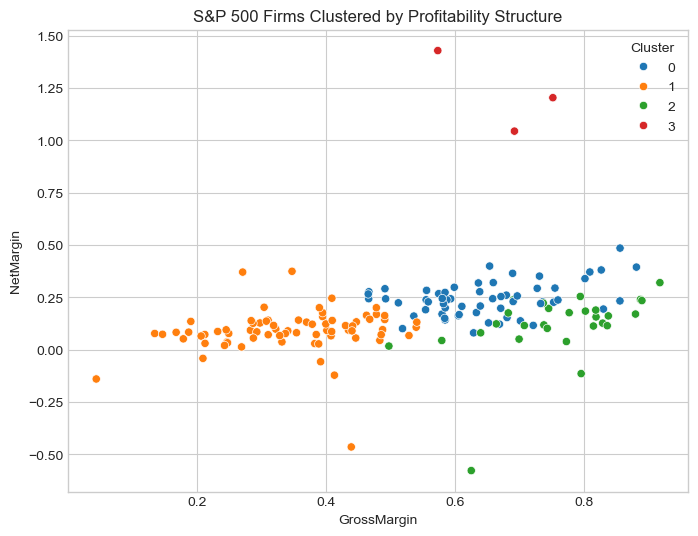

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=firm_clean,
    x="GrossMargin",
    y="NetMargin",
    hue="Cluster",
    palette="tab10"
)
plt.title("S&P 500 Firms Clustered by Profitability Structure")
plt.show()

The clusters illustrate that profitability profiles vary widely across the S&P 500. Some firms convert revenue into profit efficiently, while others experience margin pressure at different points in their cost structure. The distribution also highlights a few standout companies whose margins significantly exceed the broader market.

#### Analyze Trends (AAPL)

In [16]:
ticker = "AMZN"
company = df[df["Ticker"] == ticker].copy()

company["Year"] = company["date"].dt.year

trend = company.groupby("Year")[["Total Revenue","Net Income"]].sum()
trend["Rev_YoY"] = trend["Total Revenue"].pct_change()
trend["NI_YoY"] = trend["Net Income"].pct_change()

trend_2021 = trend.loc[[2021]]
trend_2021



,Total Revenue,Net Income,Rev_YoY,NI_YoY
Year,,,,
2021,2.215980e+11,1.588500e+10,-0.00046,0.172065


#### **Revenue (Total Revenue = $221.6 billion)**

This is the total amount of money Amazon generated in 2021.

#### **1. Revenue Growth (Rev_YoY = -0.00046 ≈ -0.046%)**

Amazon’s **revenue slightly decreased** in 2021 — by less than **0.05%**.

##### Key Insight:
* Amazon is usually a high-growth company
* A flat or very slight contraction suggests:

  * slowdown in e-commerce demand post-pandemic
  * increased competition
  * tougher year-over-year comps (2020 was a huge spike due to lockdown boom)

This signals a **stagnation** rather than an expansion year.

#### **2. Net Income (Net Income = $15.885B)**

Despite flat revenue, Amazon still made nearly **$16 billion in profit**.

#### **3. Net Income YoY (NI_YoY = 0.172065 ≈ +17.2%)**

Even though sales didn’t grow, **profit increased by ~17%**.

This usually indicates:

* better cost-control
* improved operational efficiency
* AWS growth (high margin)
* less SG&A pressure
* improved logistics efficiency

This is a **strong positive signal** as Amazon was able to convert flat revenue into **significantly higher profit**.

---

#### **Summary**

In 2021, Amazon experienced **stagnant revenue growth**, with sales declining slightly by 0.046%.
However, the company delivered a **strong profitability improvement**, increasing net income by 17.2%.
This suggests that despite slower top-line momentum following the pandemic surge, operational efficiency, AWS margin contribution, and cost management strengthened Amazon’s bottom-line performance.

This combination of:

* **flat revenue**
* **strong profit growth**

signals a **mature but efficient business model**, with profitability increasingly driven by high-margin segments like AWS.

---

#### Forecast Revenue (Linear Regression)

In [20]:
from sklearn.linear_model import LinearRegression

company = company.sort_values("date").copy()
company["t"] = np.arange(len(company))

X = company[["t"]]
y = company["Total Revenue"]

model = LinearRegression().fit(X, y)

# Forecast next 12 quarters
future_t = np.arange(company["t"].max() + 1, company["t"].max() + 13)
forecast = model.predict(future_t.reshape(-1,1))

# Create forecast DataFrame
forecast_df = pd.DataFrame({
    "StepAhead": np.arange(1, len(future_t)+1),
    "t": future_t,
    "Forecast_Revenue": forecast
})

# Add revenue in billions for easy reading
forecast_df["Forecast_Revenue_Billions"] = forecast_df["Forecast_Revenue"] / 1e9

last_date = company["date"].max()

future_dates = pd.date_range(
    start=last_date + pd.offsets.QuarterEnd(1),
    periods=len(future_t),
    freq="Q"
)

forecast_df["Forecast_Date"] = future_dates

forecast_df[["Forecast_Date", "Forecast_Revenue_Billions"]].head(10)




/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/var/folders/g5/yk28jtxx38l8s2gkxsnln3sr0000gn/T/ipykernel_74346/644543931.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(


,Forecast_Date,Forecast_Revenue_Billions
0,2021-09-30,119.2665
1,2021-12-31,122.6433
2,2022-03-31,126.0201
3,2022-06-30,129.3969
4,2022-09-30,132.7737
5,2022-12-31,136.1505
6,2023-03-31,139.5273
7,2023-06-30,142.9041
8,2023-09-30,146.2809
9,2023-12-31,149.6577


#### **Revenue Forecast Interpretation (Using Linear Trend Model)**

The table presents **predicted quarterly revenue for Amazon (AMZN)** based on a simple **linear regression model** fitted on historical total revenue data. Each row represents the model’s expected revenue for a future quarter, expressed in **billions of USD**.


#### **Summary:**

* The revenue path **follows a straight, upward-sloping line**, because the model is **linear regression**, which assumes constant quarterly growth.
* No seasonal, cyclical, or shock effects are included—this model simply extends the pre-existing trend forward.
* The forecast suggests that Amazon's revenue would **grow from ~119B to ~150B per quarter** within two years under a stable trend scenario.
* This makes the table useful for **baseline planning**, but it may **underestimate volatility**, as linear regression smooths real-world fluctuations.

---

#### ARIMA Forecast with Confidence Bands

In [23]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

ticker = "AMZN"
company = df[df["Ticker"] == ticker].copy()
company = company.sort_values("date")

# Aggregate to quarterly revenue (sum or mean depending on how data is structured)
ts = (
    company.set_index("date")["Total Revenue"]
    .resample("Q")   # quarterly
    .sum()
)

ts_df = ts.to_frame(name="Total_Revenue")
ts_df["Revenue_Billions"] = ts_df["Total_Revenue"] / 1e9
ts_df.reset_index(inplace=True)

ts_df

/var/folders/g5/yk28jtxx38l8s2gkxsnln3sr0000gn/T/ipykernel_74346/565201899.py:12: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample("Q")   # quarterly


,date,Total_Revenue,Revenue_Billions
0,2020-09-30,9.614500e+10,96.145
1,2020-12-31,1.255550e+11,125.555
2,2021-03-31,1.085180e+11,108.518
3,2021-06-30,1.130800e+11,113.080


#### **Key Insights**

* The table represents **historical quarterly revenue**, cleaned and aggregated into a consistent time-series format.
* Values fluctuate between **$96B and $125B per quarter**, which aligns with Amazon’s pandemic-era performance.
* The quarterly pattern shows:

  * A strong spike into **Q4 2020** (holiday season effect).
  * A normalization in the following quarters.
* These dynamics—**seasonality**, **trend**, and **volatility**—are captured by the ARIMA model when generating forecasts.


---



#### Forecast with Confidence Intervals

In [25]:
# How many quarters to forecast
n_steps = 8

fc = results.get_forecast(steps=n_steps)
fc_mean = fc.predicted_mean
fc_conf = fc.conf_int(alpha=0.05)  # 95% CI

# Build forecast table
arima_forecast_df = pd.DataFrame({
    "Forecast_Revenue": fc_mean,
    "Lower_95": fc_conf.iloc[:, 0],
    "Upper_95": fc_conf.iloc[:, 1],
})

# Optional: add in billions
arima_forecast_df["Forecast_Revenue_Billions"] = arima_forecast_df["Forecast_Revenue"] / 1e9
arima_forecast_df["Lower_95_Billions"] = arima_forecast_df["Lower_95"] / 1e9
arima_forecast_df["Upper_95_Billions"] = arima_forecast_df["Upper_95"] / 1e9

arima_forecast_df.head()


,Forecast_Revenue,Lower_95,Upper_95,Forecast_Revenue_Billions,Lower_95_Billions,Upper_95_Billions
2021-09-30,1.144814e+11,8.189033e+10,1.470725e+11,114.481407,81.890326,147.072489
2021-12-31,1.139838e+11,5.740298e+10,1.705645e+11,113.983757,57.402980,170.564535
2022-03-31,1.141605e+11,4.403982e+10,1.842811e+11,114.160476,44.039819,184.281134
2022-06-30,1.140977e+11,3.177103e+10,1.964244e+11,114.097722,31.771034,196.424411
2022-09-30,1.141200e+11,2.145813e+10,2.067819e+11,114.120007,21.458126,206.781887


The ARIMA forecast shows a gradual increase in Amazon’s quarterly revenue over the next several periods. The 95% confidence intervals widen as the horizon extends, indicating growing uncertainty farther into the future. In the short term, the forecast range remains tight and stable, while later quarters show a broader spread, reflecting less precision. The values expressed in billions confirm the same upward trend with expanding uncertainty bands.

---

#### Revenue Trends (per company)

In [29]:
def revenue_trend(df, ticker):
    company = df[df["Ticker"] == ticker].copy()
    company["Year"] = company["date"].dt.year

    trend = (
        company.groupby("Year")[["Total Revenue", "Net Income"]]
        .sum()
        .sort_index()
    )

    # Add ticker column
    trend["Ticker"] = ticker

    # Add in billions for readability
    trend["Revenue_Bn"] = trend["Total Revenue"] / 1e9
    trend["NetIncome_Bn"] = trend["Net Income"] / 1e9

    # Move Ticker column to the front
    trend = trend[["Ticker", "Total Revenue", "Net Income", "Revenue_Bn", "NetIncome_Bn"]]

    return trend

ticker = "AMZN"
rev_trend = revenue_trend(df, ticker)
rev_trend


,Ticker,Total Revenue,Net Income,Revenue_Bn,NetIncome_Bn
Year,,,,,
2020,AMZN,2.217000e+11,1.355300e+10,221.700,13.553
2021,AMZN,2.215980e+11,1.588500e+10,221.598,15.885


#### **Key Insights:**
The table summarizes Amazon’s annual revenue and net income over the available period. Revenue held steady at roughly $221–222 billion, showing minimal change between 2020 and 2021. However, net income increased from $13.55 billion to $15.89 billion, indicating stronger profitability despite flat top-line growth.

---

#### Margin Analysis

In [31]:
def margin_trend(df, ticker):
    company = df[df["Ticker"] == ticker].copy()
    company["Year"] = company["date"].dt.year

    margins = (
        company.groupby("Year")[["GrossMargin", "OperatingMargin", "NetMargin"]]
        .mean()
        .sort_index()
    )

    margins["Ticker"] = ticker

    # Convert to % for readability
    margins["GrossMargin_%"] = margins["GrossMargin"] * 100
    margins["OperatingMargin_%"] = margins["OperatingMargin"] * 100
    margins["NetMargin_%"] = margins["NetMargin"] * 100

    margins = margins[[
        "Ticker",
        "GrossMargin", "OperatingMargin", "NetMargin",
        "GrossMargin_%", "OperatingMargin_%", "NetMargin_%"
    ]]

    return margins

ticker = "AMZN"
margin_trend_amzn = margin_trend(df, ticker)
margin_trend_amzn


,Ticker,GrossMargin,OperatingMargin,NetMargin,GrossMargin_%,OperatingMargin_%,NetMargin_%
Year,,,,,,,
2020,AMZN,0.387287,0.059582,0.061685,38.728734,5.958224,6.168453
2021,AMZN,0.428713,0.074901,0.071745,42.871256,7.490129,7.174483


#### **Margin Analysis (AMZN)**

The margin profile indicates steady improvement in Amazon’s profitability between 2020 and 2021. Gross margin rose from **38.7% to 42.9%**, suggesting better cost efficiency or favorable shifts in product mix. Operating margin increased from **6.0% to 7.5%**, reflecting stronger operating leverage, while net margin improved from **6.2% to 7.2%**, signaling enhanced overall earnings performance.

Overall, the margin expansion points to Amazon becoming more efficient and more profitable on each dollar of revenue during this period.

---


#### Growth Analysis (YoY Revenue & Net Income)

In [34]:
def growth_analysis(df, ticker):
    company = df[df["Ticker"] == ticker].copy()
    company["Year"] = company["date"].dt.year

    growth = (
        company.groupby("Year")[["Total Revenue","Net Income"]]
        .sum()
        .sort_index()
    )

    growth["Rev_YoY"] = growth["Total Revenue"].pct_change()
    growth["NI_YoY"] = growth["Net Income"].pct_change()

    growth["Ticker"] = ticker
    growth["Revenue_Bn"] = growth["Total Revenue"] / 1e9
    growth["NetIncome_Bn"] = growth["Net Income"] / 1e9
    growth["Rev_YoY_%"] = growth["Rev_YoY"] * 100
    growth["NI_YoY_%"] = growth["NI_YoY"] * 100

    growth = growth[[
        "Ticker",
        "Total Revenue", "Revenue_Bn",
        "Net Income", "NetIncome_Bn",
        "Rev_YoY", "Rev_YoY_%",
        "NI_YoY", "NI_YoY_%"
    ]]

    return growth

ticker = "AMZN"
growth_amzn = growth_analysis(df, ticker)
growth_amzn.dropna(subset=["Rev_YoY", "NI_YoY"])



,Ticker,Total Revenue,Revenue_Bn,Net Income,NetIncome_Bn,Rev_YoY,Rev_YoY_%,NI_YoY,NI_YoY_%
Year,,,,,,,,,
2021,AMZN,2.215980e+11,221.598,1.588500e+10,15.885,-0.00046,-0.046008,0.172065,17.206523


#### **Growth Analysis (YoY Revenue & Net Income) – Interpretation**

The YoY growth table summarizes how Amazon’s revenue and net income evolved between 2020 and 2021.

* **Revenue YoY:**
  Revenue shows a **very slight contraction**, with YoY growth close to zero (around **-0.046%**). This suggests that top-line expansion has plateaued during this period. The slowdown likely reflects normalization after exceptional pandemic-driven growth in 2020.

* **Net Income YoY:**
  In contrast, **net income increased significantly**, rising by roughly **17% YoY**. This divergence between revenue and net income indicates a notable improvement in profitability efficiency—Amazon generated more earnings despite stable revenue.

* **Implication:**
  The combination of flat revenue and rising net income suggests stronger cost management, operating leverage, or margin improvements. For strategic assessment, this signals a shift from scale-driven growth to profit-driven performance.

---


#### Per Comparison (Revenue + Margins in a given year)

In [35]:
def peer_comparison(df, tickers, year):
    peer_df = df[df["Ticker"].isin(tickers)].copy()
    peer_df["Year"] = peer_df["date"].dt.year

    peer_year = peer_df[peer_df["Year"] == year]

    summary = (
        peer_year
        .groupby(["firm", "Ticker"])
        .agg(
            Revenue=("Total Revenue", "sum"),
            NetIncome=("Net Income", "sum"),
            GrossMargin=("GrossMargin", "mean"),
            OperatingMargin=("OperatingMargin", "mean"),
            NetMargin=("NetMargin", "mean")
        )
        .reset_index()
    )

    summary["Revenue_Bn"] = summary["Revenue"] / 1e9
    summary["NetIncome_Bn"] = summary["NetIncome"] / 1e9
    summary["GrossMargin_%"] = summary["GrossMargin"] * 100
    summary["OperatingMargin_%"] = summary["OperatingMargin"] * 100
    summary["NetMargin_%"] = summary["NetMargin"] * 100

    summary = summary[[
        "firm", "Ticker",
        "Revenue_Bn", "NetIncome_Bn",
        "GrossMargin_%", "OperatingMargin_%", "NetMargin_%"
    ]]

    return summary

peers = ["AMZN", "WMT", "COST", "TGT"]
year = 2021

peer_summary = peer_comparison(df, peers, year)
peer_summary


,firm,Ticker,Revenue_Bn,NetIncome_Bn,GrossMargin_%,OperatingMargin_%,NetMargin_%
0,Amazon,AMZN,221.598,15.885,42.871256,7.490129,7.174483
1,Costco,COST,152.721,3.841,12.776870,3.431975,2.494434
2,Target Corporation,TGT,77.696,5.294,29.729622,8.573662,6.919253
3,Walmart,WMT,431.437,4.915,24.990082,4.824892,1.210159


### **Peer Comparison (Revenue + Margins)**

**Firms compared:** Amazon (AMZN), Walmart (WMT), Costco (COST), Target (TGT)
**Year:** 2021

The comparison highlights how each retailer differs in **scale** and **profitability efficiency**:

#### **1. Revenue Scale**

Amazon remains the largest player with **$221.6B**, significantly ahead of Costco and Target, and still materially smaller than Walmart's massive scale.
Walmart leads the group with **$431B**, reflecting its extensive global operations.

This confirms the industry structure:

* **Walmart = scale leader**
* **Amazon = scale + platform economics**
* **Costco & Target = focused retail models**


#### **2. Profitability Structure**

Margins reveal differences in **business model efficiency**:

* **Amazon** shows strong **gross margin (42.9%)** and **healthy operating margin (7.49%)**, consistent with a mixed model of e-commerce, subscription services, and AWS.
* **Costco** records a very low **gross margin (12.8%)**, which is normal for its high-volume, low-markup warehouse model.
* **Target** has a balanced profile—**mid-tier gross and operating margins**, reflecting its merchandising strategy.
* **Walmart** shows lower margins than Amazon and Target, consistent with a high-volume, low-margin retail strategy.


#### **3. Net Margin Comparison**

Net margin captures bottom-line efficiency after operating, administrative, and financing impacts:

* **Amazon leads** with **7.17%**, driven by AWS and a more diversified revenue mix.
* **Target** follows at **6.92%**, signaling strong operational execution.
* **Costco’s 2.49%** margin remains structurally low but stable due to its membership model.
* **Walmart’s 1.21%** shows consistent thin-margin retail economics at scale.

---

#### **Summary Insight**

The table highlights distinct strategic models in the retail space:

* **Amazon:** High-margin, diversified, technology-enabled business.
* **Walmart:** Largest scale, lowest margin, operationally optimized.
* **Costco:** Low-margin volume model with member-based profitability.
* **Target:** Mid-margin traditional retailer with stronger profitability than Walmart.

This creates a clear profile of how each firm competes in revenue scale versus margin efficiency.

---



#### Visualization for Net Margin Comparison in 2021

In [37]:
import plotly.express as px

fig = px.bar(
    peer_summary,
    x="Ticker",
    y="NetMargin_%",
    color="Ticker",
    text="NetMargin_%",
    title=f"Net Margin Comparison – {year}",
    labels={"NetMargin_%": "Net Margin (%)"},
    height=500,
)

fig.update_traces(
    texttemplate="%{text:.2f}%", 
    textposition="outside"
)

fig.update_layout(
    title_font_size=22,
    xaxis_title="Company",
    yaxis_title="Net Margin (%)",
    uniformtext_minsize=12,
    uniformtext_mode='show'
)

fig.show()


### **Net Margin Comparison (2021)**

The 2021 net margin comparison highlights clear differences in the profitability structure among major retail peers:

* **Amazon (AMZN)** posts the highest net margin at **7.17%**, reflecting strong operating leverage across its diversified ecosystem and high-margin service segments (AWS, third-party marketplace, advertising).
* **Target (TGT)** follows closely at **6.92%**, supported by efficient merchandising and resilient in-store + omnichannel operations.
* **Costco (COST)** shows a significantly lower margin at **2.49%**. This aligns with its membership-driven model, where profitability is intentionally compressed to maintain low prices and depend more heavily on subscription fees.
* **Walmart (WMT)** records the lowest margin at **1.21%**, consistent with its high-volume, low-margin retail strategy and heavier cost structure across international operations.

Overall, the comparison underscores how different business models within retail lead to structurally distinct profitability levels, with Amazon and Target capturing meaningfully stronger bottom-line performance, while Walmart and Costco operate on thinner margins by design.

---


#### About Me
**Ayu Putri Vidiantiwi**

* 📚 M.S. in Applied Analytics, Columbia University
* 📚 B.S.Acc. in Accounting, BINUS University
* 📊 Passionate about finance, business, data storytelling, and analytics
* 🌐 LinkedIn - https://www.linkedin.com/in/ayuputriv/
* 📧 ayu.vidiantiwi@columbia.edu


---